In [1]:
import sys
original_sys_path = sys.path.copy()
sys.path.append('../')
from utils_models import *

dq.set_device('cpu')
import warnings
warnings.filterwarnings("ignore")

In [2]:
solver = dq.solver.Tsit5(
                    rtol= 1e-06,
                    atol= 1e-06,
                    safety_factor= 0.9,
                    min_factor= 0.2,
                    max_factor = 5.0,
                    max_steps = int(1e4*1000),
                )

n_lvls_fluxonium = 20
n_lvls_transmon = 4


Ej_f = 2.7
Ec_f = 0.6
El_f = 0.13
qsf = qs.Fluxonium.create(
    n_lvls_fluxonium,
    {"Ej": Ej_f, "Ec": Ec_f, "El": El_f, "phi_ext": 0.0},
    N_pre_diag=100,
    use_linear = False
    )
g_tf = 0.2
Ec_t = 0.2


def truncate(data: jnp.array):
    return data[:,:]

tot_dim = 80


(-1e-05, 0.0001)

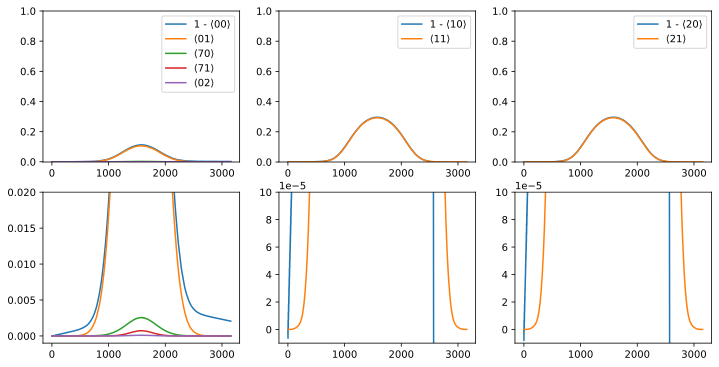

In [3]:

sigma = 2.47029937e+02 / np.sqrt(2*np.pi)  *4
amp_with_2pi = 9.13069185e-03 *5
Ej_t =  34.1
w_d = 7.19
beta = 0.0
# params =  jnp.array([
#                 sigma,
#                 amp_with_2pi,
#                 Ej_t,
#                 w_d,
#                 beta
#             ])
# sigma = params[0]
# amp_with_2pi = params[1]
# Ej_t = params[2]
# w_d = params[3]
# beta = params[4]



Ec_t = 0.2
qst = MyTransmon.create(
    N = n_lvls_transmon,
    params = {"Ej": Ej_t, "Ec": Ec_t,"ng":0.0},
    N_max_charge=10
    )


devices = [qsf, qst]
f_indx = 0
t_indx = 1
Ns = [device.N for device in devices]
fn = qs.promote(qsf.ops["n"], f_indx, Ns)
tn = qs.promote(qst.ops['n'], t_indx, Ns)

g_tf = 0.2
system = qs.System.create(devices, couplings=[
    g_tf *  fn @ tn
    ])
system.params["g_tf"] = g_tf
system_evals_sorted, system_evecs_sorted, product_indices_sorted_by_eval = calculate_eig(Ns, system.get_H())
driven_op = transform_op_into_dressed_basis_jax(tn, system_evecs_sorted.T)

pulse_length = 8*sigma
pulse_shape_args={
    'w_d': w_d,
    'amp': amp_with_2pi/(2*jnp.pi),
    'duration': pulse_length,
    'sigma': sigma,
    'beta':beta
}      

t_tot = pulse_length 
tlist = jnp.linspace(0,t_tot,int(t_tot))

def _H(t):
    _H =  2 * jnp.pi *truncate(jnp.diag(system_evals_sorted))
    _H += truncate(driven_op) * modified_drag_pulse(t, pulse_shape_args)
    return _H 
H =  dq.timecallable(_H)

psi0_list = [truncate(dq.basis(tot_dim,find_closest_dressed_index(l*qst.N, product_indices_sorted_by_eval)))
                    for l in [0,1,2]] #00,10,20


e_ops = []
for ql in range(8):
    for tl in range(4):
        e_ops.append(truncate(dq.basis_dm(math.prod(Ns),  find_closest_dressed_index(ql*qst.N+tl, product_indices_sorted_by_eval))))

result = dq.sesolve(
            H = H,
            psi0 = psi0_list,
            tsave = tlist,
            solver = solver,
            exp_ops = e_ops
            )

colors = ['green','red','darkorange']
fig,axes = plt.subplots(2,3,figsize = (12,6))
for col, levels_list in zip([0,1,2],
                    [
                        [(0,0),(0,1),(7,0),(7,1),(0,2)],
                        [(1,0),(1,1)],
                        [(2,0),(2,1)]
                    ]):
    for row in [0,1]:
        for (ql,tl) in levels_list:
            i = ql*4+tl
            if (ql,tl) not in [(0,0), (1,0),(2,0)]:
                axes[row, col].plot(tlist,result.expects[col][i],label = rf"$\langle{ql}{tl}\rangle$")
            else:
                axes[row, col].plot(tlist,1 - result.expects[col][i],label = rf"1 - $\langle{ql}{tl}\rangle$")
    axes[0,col].legend()
    # axes[1,col].axvline(x=270, color='b', linestyle='--')
    # axes[1,col].set_xlim(260,280)


axes[0,0].set_ylim(-1e-3,1)
axes[0,1].set_ylim(-1e-5,1)
axes[0,2].set_ylim(-1e-5,1)

axes[1,0].set_ylim(-1e-3,2e-2)
axes[1,1].set_ylim(-1e-5,1e-4)
axes[1,2].set_ylim(-1e-5,1e-4)


In [48]:
def trapezoidal_rule(tlist, ylist):
    n = len(tlist)
    area = 0.0
    for i in range(1, n):
        delta_t = tlist[i] - tlist[i - 1]
        avg_y = 0.5 * (ylist[i] + ylist[i - 1])
        trapezoid_area = delta_t * avg_y
        area += trapezoid_area
    return area


def modified_drag_pulse_no_cos(t, args):
    w_d = args['w_d']
    amp = args['amp']
    duration = args['duration']
    sigma = args['sigma']
    beta = args['beta']
    
    a = jnp.exp(-0.5 * ((0 - duration / 2) / sigma) ** 2)
    gaussian = (jnp.exp(-0.5 * ((t - duration / 2) / sigma) ** 2) - a) / (1 - a)
    derivative = 1j * beta * (-1 / sigma ** 2) * (t - duration / 2) * gaussian
    modified_pulse =  (gaussian + derivative) * amp * 2*jnp.pi
    return modified_pulse


sigma = 2.47029937e+02 / np.sqrt(2*np.pi)

t_tot = 7 * sigma

tlist = jnp.linspace(0,t_tot,int(t_tot))
ylist = modified_drag_pulse_no_cos(tlist, {
                                'w_d': 7.17878953,
                                'amp': 9.13069185e-03/(2*jnp.pi),
                                'duration': t_tot,
                                'sigma': sigma,
                                'beta':0.0
                            }      )
trapezoidal_rule(tlist, ylist)


Array(2.24563833+0.j, dtype=complex128)

In [43]:

def square_pulse_with_rise_fall_no_cos(t,
                                args = {}):
    
    w_d = args['w_d']
    amp = args['amp']
    t_start = args.get('t_start', 0)  # Default start time is 0
    t_rise = args.get('t_rise', 0)  # Default rise time is 0 for no rise
    t_square = args.get('t_square', 0)  # Duration of constant amplitude

    def cos_modulation():
        return 2 * jnp.pi * amp 
    
    t_fall_start = t_start + t_rise + t_square  # Start of fall
    t_end = t_fall_start + t_rise  # End of the pulse

    before_pulse_start = jnp.less(t, t_start)
    during_rise_segment = jnp.logical_and(jnp.greater(t_rise, 0), jnp.logical_and(jnp.greater_equal(t, t_start), jnp.less_equal(t, t_start + t_rise)))
    constant_amplitude_segment = jnp.logical_and(jnp.greater(t, t_start + t_rise), jnp.less_equal(t, t_fall_start))
    during_fall_segment = jnp.logical_and(jnp.greater(t_rise, 0), jnp.logical_and(jnp.greater(t, t_fall_start), jnp.less_equal(t, t_end)))

    return jnp.where(before_pulse_start, 0,
                    jnp.where(during_rise_segment, jnp.sin(jnp.pi * (t - t_start) / (2 * t_rise)) ** 2 * cos_modulation(),
                            jnp.where(constant_amplitude_segment, cos_modulation(),
                                        jnp.where(during_fall_segment, jnp.sin(jnp.pi * (t_end - t) / (2 * t_rise)) ** 2 * cos_modulation(), 0))))


t_tot = 2.47029937e+02+30 
tlist = jnp.linspace(0,t_tot,int(t_tot))
ylist = square_pulse_with_rise_fall_no_cos(tlist, {
                                'w_d': 7.17878953,
                                'amp': 9.13069185e-03/(2*jnp.pi),
                                't_rise': 30,
                                't_square': 2.47029937e+02 - 30,
                            }      )
trapezoidal_rule(tlist, ylist)

Array(2.25555358, dtype=float64)